# Rede Neural do Zero — Demo MNIST

Demonstração de uma MLP implementada manualmente com NumPy puro, treinada no dataset MNIST (dígitos manuscritos 0–9).

**Stack:** Python 3.11+ · NumPy · Matplotlib  
**Proibido:** scikit-learn, PyTorch, TensorFlow, Keras

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import gzip
import struct
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from src.activations import relu, relu_derivada, softmax
from src.layers import Layer
from src.losses import cross_entropy, cross_entropy_derivada
from src.network import Network
from src.utils import normalizar, one_hot, dividir

## 2. Download e carregamento do MNIST

Os arquivos são baixados do repositório oficial no formato IDX binário e lidos manualmente — sem bibliotecas de ML.

In [2]:
PASTA_DADOS = Path('../data/mnist')
PASTA_DADOS.mkdir(parents=True, exist_ok=True)

ARQUIVOS = {
    'train_imgs': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz',
    'train_lbls': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz',
    'test_imgs':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz',
    'test_lbls':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz',
}

def _baixar(url: str, destino: Path) -> None:
    """Baixa o arquivo se ainda não existir."""
    if not destino.exists():
        print(f'Baixando {destino.name}...')
        urllib.request.urlretrieve(url, destino)

def _ler_imagens(caminho: Path) -> np.ndarray:
    """Lê arquivo IDX de imagens e retorna array (n, 784)."""
    with gzip.open(caminho, 'rb') as f:
        magic, n, h, w = struct.unpack('>IIII', f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, h * w)

def _ler_labels(caminho: Path) -> np.ndarray:
    """Lê arquivo IDX de rótulos e retorna vetor (n,)."""
    with gzip.open(caminho, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

# Download
for nome, url in ARQUIVOS.items():
    _baixar(url, PASTA_DADOS / f'{nome}.gz')

# Leitura
X_treino_raw = _ler_imagens(PASTA_DADOS / 'train_imgs.gz')
y_treino_raw = _ler_labels(PASTA_DADOS / 'train_lbls.gz')
X_teste_raw  = _ler_imagens(PASTA_DADOS / 'test_imgs.gz')
y_teste_raw  = _ler_labels(PASTA_DADOS / 'test_lbls.gz')

print(f'Treino: {X_treino_raw.shape} | Teste: {X_teste_raw.shape}')

Treino: (60000, 784) | Teste: (10000, 784)


## 3. Pré-processamento

In [3]:
# Normalização: pixels [0, 255] → média 0, desvio 1
X_treino = normalizar(X_treino_raw.astype(float))
X_teste  = normalizar(X_teste_raw.astype(float))

# Rótulos inteiros → one-hot
y_treino = one_hot(y_treino_raw, n_classes=10)
y_teste  = one_hot(y_teste_raw,  n_classes=10)

# Subconjunto de validação a partir do treino
X_tr, X_val, y_tr, y_val = dividir(X_treino, y_treino, proporcao_treino=0.9, semente=42)

print(f'Treino: {X_tr.shape} | Validação: {X_val.shape} | Teste: {X_teste.shape}')

Treino: (54000, 784) | Validação: (6000, 784) | Teste: (10000, 784)


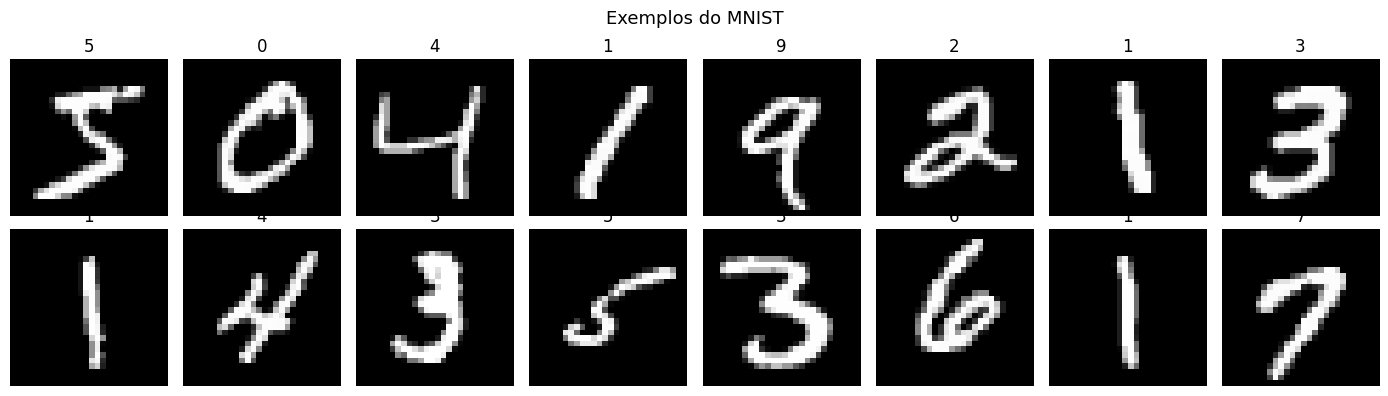

In [4]:
# Visualização de exemplos do conjunto de treino
fig, eixos = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(eixos.flat):
    ax.imshow(X_treino_raw[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_treino_raw[i]))
    ax.axis('off')
plt.suptitle('Exemplos do MNIST', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Construção da rede

Arquitetura: **784 → 128 (ReLU) → 64 (ReLU) → 10 (Softmax)**

In [5]:
np.random.seed(42)

rede = Network([
    Layer(784, 128, relu, relu_derivada),
    Layer(128,  64, relu, relu_derivada),
    Layer( 64,  10, softmax, ativacao_derivada=None),
])

print('Camadas:')
for i, c in enumerate(rede.camadas):
    print(f'  [{i}] W={c.W.shape}  b={c.b.shape}  ativação={c.ativacao.__name__}')

Camadas:
  [0] W=(784, 128)  b=(1, 128)  ativação=relu
  [1] W=(128, 64)  b=(1, 64)  ativação=relu
  [2] W=(64, 10)  b=(1, 10)  ativação=softmax


## 5. Treinamento

In [6]:
EPOCHS          = 20
TAXA_APRENDIZADO = 0.01
TAMANHO_LOTE    = 64

historico = rede.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    taxa_aprendizado=TAXA_APRENDIZADO,
    funcao_custo=cross_entropy,
    funcao_custo_derivada=cross_entropy_derivada,
    tamanho_lote=TAMANHO_LOTE,
    verbose=True,
)

Época    1/20 — loss: 0.622402


Época    2/20 — loss: 0.262450


Época    4/20 — loss: 0.170011


Época    6/20 — loss: 0.130584


Época    8/20 — loss: 0.106527


...

Época   12/20 — loss: 0.076602


Época   14/20 — loss: 0.065653


Época   16/20 — loss: 0.057515


Época   18/20 — loss: 0.050539


Época   20/20 — loss: 0.044754


## 6. Curva de loss

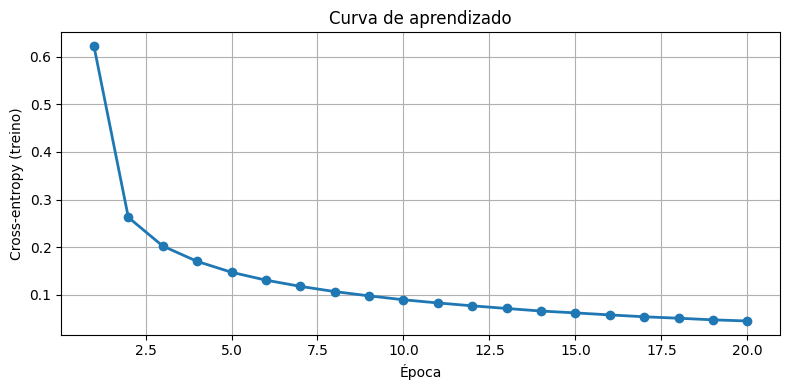

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), historico, marker='o', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Cross-entropy (treino)')
plt.title('Curva de aprendizado')
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Avaliação

In [8]:
loss_val, acc_val   = rede.evaluate(X_val,   y_val,   cross_entropy)
loss_test, acc_test = rede.evaluate(X_teste,  y_teste,  cross_entropy)

print(f'Validação — loss: {loss_val:.4f}  |  acurácia: {acc_val*100:.2f}%')
print(f'Teste     — loss: {loss_test:.4f}  |  acurácia: {acc_test*100:.2f}%')

Validação — loss: 0.1413  |  acurácia: 96.52%
Teste     — loss: 0.1269  |  acurácia: 96.70%


## 8. Exemplos de predição

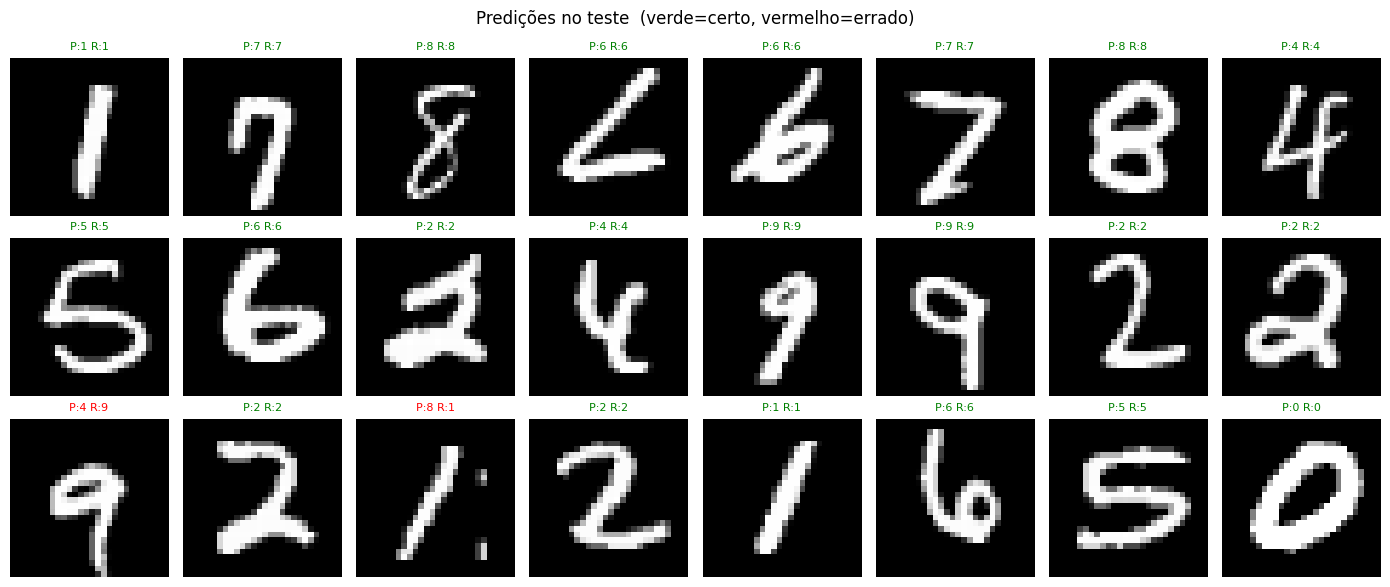

In [9]:
y_pred_teste = rede.predict(X_teste)
classes_pred = np.argmax(y_pred_teste, axis=1)
classes_real = y_teste_raw

fig, eixos = plt.subplots(3, 8, figsize=(14, 6))
indices = np.random.choice(len(X_teste_raw), 24, replace=False)

for ax, idx in zip(eixos.flat, indices):
    correto = classes_pred[idx] == classes_real[idx]
    cor = 'green' if correto else 'red'
    ax.imshow(X_teste_raw[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'P:{classes_pred[idx]} R:{classes_real[idx]}', color=cor, fontsize=8)
    ax.axis('off')

plt.suptitle('Predições no teste  (verde=certo, vermelho=errado)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Matriz de confusão

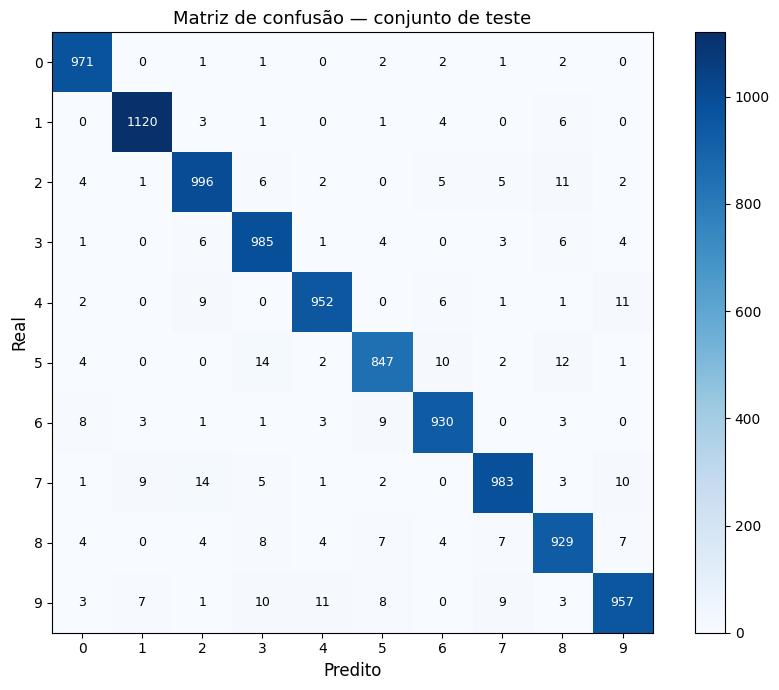


Acurácia por dígito:
  Dígito 0: 971/980  (99.1%)
  Dígito 1: 1120/1135  (98.7%)
  Dígito 2: 996/1032  (96.5%)
  Dígito 3: 985/1010  (97.5%)
  Dígito 4: 952/982  (96.9%)
  Dígito 5: 847/892  (95.0%)
  Dígito 6: 930/958  (97.1%)
  Dígito 7: 983/1028  (95.6%)
  Dígito 8: 929/974  (95.4%)
  Dígito 9: 957/1009  (94.8%)


In [10]:
# Calcula a matriz de confusão manualmente (sem sklearn)
n_classes = 10
matriz = np.zeros((n_classes, n_classes), dtype=int)
for real, pred in zip(classes_real, classes_pred):
    matriz[real, pred] += 1

# Visualização
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(matriz, cmap='Blues')

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(range(n_classes))
ax.set_yticklabels(range(n_classes))
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de confusão — conjunto de teste', fontsize=13)

# Valores dentro das células
limiar = matriz.max() / 2
for i in range(n_classes):
    for j in range(n_classes):
        cor_texto = 'white' if matriz[i, j] > limiar else 'black'
        ax.text(j, i, str(matriz[i, j]), ha='center', va='center',
                fontsize=9, color=cor_texto)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Acurácia por classe
print('\nAcurácia por dígito:')
for d in range(n_classes):
    total = matriz[d].sum()
    acertos = matriz[d, d]
    print(f'  Dígito {d}: {acertos}/{total}  ({100*acertos/total:.1f}%)')

## 10. Benchmark: nossa implementação vs. bibliotecas

Comparação de **tempo de treinamento** e **acurácia no teste** entre:
- Nossa MLP implementada do zero (NumPy puro)
- `scikit-learn` MLPClassifier
- `PyTorch` (CPU)

Mesma arquitetura em todos: **784 → 128 (ReLU) → 64 (ReLU) → 10 (Softmax)** · 20 épocas · lote 64 · lr 0,01

In [11]:
import time
import warnings
warnings.filterwarnings('ignore')   # suprime ConvergenceWarning do sklearn

EPOCHS_BM = 20
TAXA_BM   = 0.01
LOTE_BM   = 64

resultados = {}

# ── Nossa implementação ────────────────────────────────────────────────────────
np.random.seed(42)
rede_bm = Network([
    Layer(784, 128, relu, relu_derivada),
    Layer(128,  64, relu, relu_derivada),
    Layer( 64,  10, softmax, ativacao_derivada=None),
])

t0 = time.perf_counter()
rede_bm.fit(
    X_tr, y_tr,
    epochs=EPOCHS_BM,
    taxa_aprendizado=TAXA_BM,
    funcao_custo=cross_entropy,
    funcao_custo_derivada=cross_entropy_derivada,
    tamanho_lote=LOTE_BM,
    verbose=False,
)
t1 = time.perf_counter()
_, acc_nossa = rede_bm.evaluate(X_teste, y_teste, cross_entropy)
resultados['Do Zero\n(NumPy)'] = {'tempo': t1 - t0, 'acuracia': acc_nossa}
print(f"Nossa implementação : {t1 - t0:6.2f}s  |  acurácia: {acc_nossa * 100:.2f}%")

# ── scikit-learn ───────────────────────────────────────────────────────────────
try:
    from sklearn.neural_network import MLPClassifier
    clf = MLPClassifier(
        hidden_layer_sizes=(128, 64), activation='relu', solver='sgd',
        learning_rate_init=TAXA_BM, batch_size=LOTE_BM,
        max_iter=EPOCHS_BM, random_state=42, verbose=False,
    )
    t0 = time.perf_counter()
    clf.fit(X_tr, np.argmax(y_tr, axis=1))
    t1 = time.perf_counter()
    acc_sk = clf.score(X_teste, y_teste_raw)
    resultados['scikit-learn\nMLPClassifier'] = {'tempo': t1 - t0, 'acuracia': acc_sk}
    print(f"scikit-learn        : {t1 - t0:6.2f}s  |  acurácia: {acc_sk * 100:.2f}%")
except ImportError:
    print("scikit-learn não instalado.")

# ── PyTorch (CPU) ──────────────────────────────────────────────────────────────
try:
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset

    X_tr_t = torch.tensor(X_tr,                    dtype=torch.float32)
    y_tr_t = torch.tensor(np.argmax(y_tr, axis=1), dtype=torch.long)
    X_te_t = torch.tensor(X_teste,                 dtype=torch.float32)
    y_te_t = torch.tensor(y_teste_raw,             dtype=torch.long)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=LOTE_BM, shuffle=True)
    torch.manual_seed(42)
    modelo_pt = nn.Sequential(
        nn.Linear(784, 128), nn.ReLU(),
        nn.Linear(128,  64), nn.ReLU(),
        nn.Linear( 64,  10),
    )
    criterio   = nn.CrossEntropyLoss()
    otimizador = optim.SGD(modelo_pt.parameters(), lr=TAXA_BM)

    t0 = time.perf_counter()
    modelo_pt.train()
    for _ in range(EPOCHS_BM):
        for Xb, yb in loader:
            otimizador.zero_grad()
            criterio(modelo_pt(Xb), yb).backward()
            otimizador.step()
    t1 = time.perf_counter()

    modelo_pt.eval()
    with torch.no_grad():
        acc_pt = (modelo_pt(X_te_t).argmax(dim=1) == y_te_t).float().mean().item()
    resultados['PyTorch\n(CPU)'] = {'tempo': t1 - t0, 'acuracia': acc_pt}
    print(f"PyTorch (CPU)       : {t1 - t0:6.2f}s  |  acurácia: {acc_pt * 100:.2f}%")
except ImportError:
    print("PyTorch não instalado.")

Nossa implementação :  27.56s  |  acurácia: 96.70%


scikit-learn        :  36.24s  |  acurácia: 97.44%


PyTorch (CPU)       :  26.31s  |  acurácia: 96.98%


Imagem salva em: D:\DOCUMENTOS\Paulo Victor\Projetos Pessoais\Rede_Neural_do_Zero\notebooks\benchmark_linkedin.png


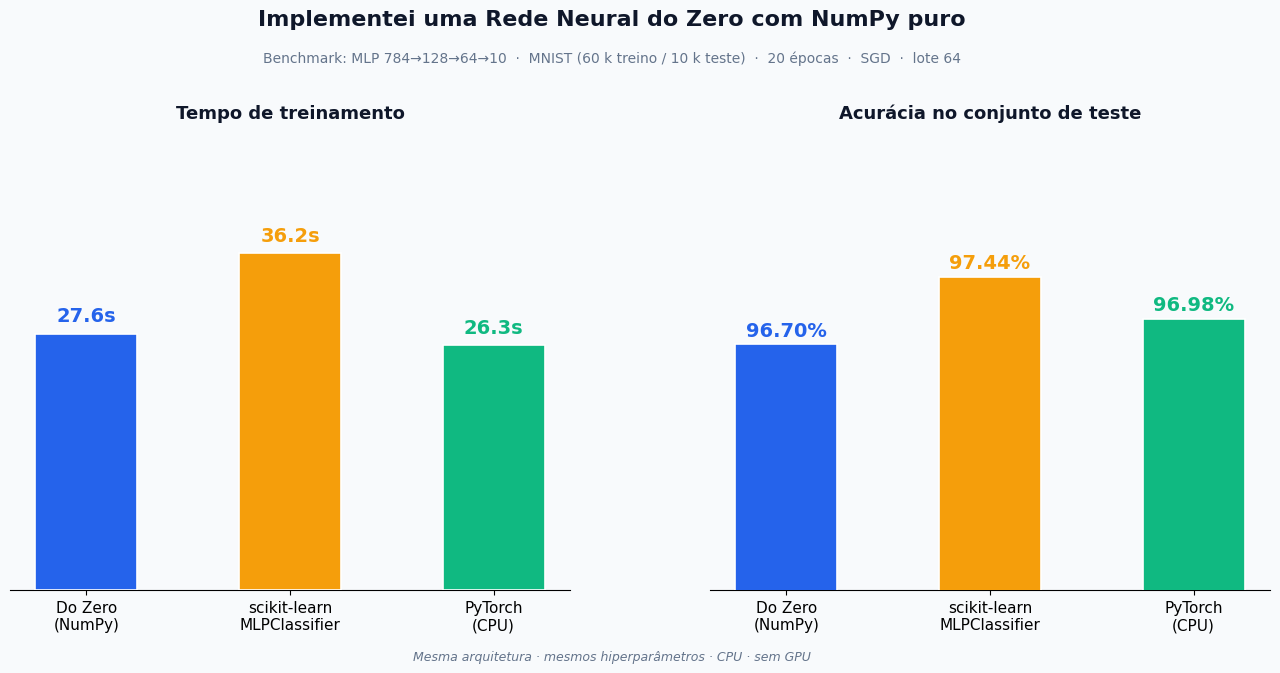

In [12]:
from pathlib import Path

# ── Paleta e estilo ────────────────────────────────────────────────────────────
CORES  = {'Do Zero\n(NumPy)': '#2563EB', 'scikit-learn\nMLPClassifier': '#F59E0B', 'PyTorch\n(CPU)': '#10B981'}
BG     = '#F8FAFC'
CINZA  = '#64748B'

labels    = list(resultados.keys())
tempos    = [resultados[k]['tempo']    for k in labels]
acuracias = [resultados[k]['acuracia'] for k in labels]
cores     = [CORES[k] for k in labels]

fig = plt.figure(figsize=(14, 7), facecolor=BG)
fig.patch.set_facecolor(BG)

# ── Título principal ───────────────────────────────────────────────────────────
fig.text(
    0.5, 0.97,
    'Implementei uma Rede Neural do Zero com NumPy puro',
    ha='center', va='top', fontsize=16, fontweight='bold', color='#0F172A',
)
fig.text(
    0.5, 0.91,
    'Benchmark: MLP 784→128→64→10  ·  MNIST (60 k treino / 10 k teste)  ·  20 épocas  ·  SGD  ·  lote 64',
    ha='center', va='top', fontsize=10, color=CINZA,
)

ax1 = fig.add_axes([0.07, 0.14, 0.40, 0.65])  # [left, bottom, width, height]
ax2 = fig.add_axes([0.57, 0.14, 0.40, 0.65])

for ax in (ax1, ax2):
    ax.set_facecolor(BG)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', left=False, labelcolor=CINZA)
    ax.tick_params(axis='x', labelsize=11)
    ax.yaxis.grid(True, color='#E2E8F0', zorder=0)
    ax.set_axisbelow(True)

# ── Subplot 1: Tempo ───────────────────────────────────────────────────────────
barras1 = ax1.bar(labels, tempos, color=cores, width=0.5, zorder=3,
                  edgecolor='white', linewidth=1.2)
ax1.set_title('Tempo de treinamento', fontsize=13, fontweight='bold',
              color='#0F172A', pad=12)
ax1.set_ylabel('segundos', color=CINZA, fontsize=10)
ax1.set_ylim(0, max(tempos) * 1.35)
ax1.yaxis.set_visible(False)

for barra, val in zip(barras1, tempos):
    ax1.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + max(tempos) * 0.025,
        f'{val:.1f}s',
        ha='center', va='bottom', fontsize=14, fontweight='bold',
        color=barra.get_facecolor(),
    )

# ── Subplot 2: Acurácia ────────────────────────────────────────────────────────
accs_pct = [a * 100 for a in acuracias]
barras2  = ax2.bar(labels, accs_pct, color=cores, width=0.5, zorder=3,
                   edgecolor='white', linewidth=1.2)
ax2.set_title('Acurácia no conjunto de teste', fontsize=13, fontweight='bold',
              color='#0F172A', pad=12)
ax2.set_ylim(94, 99)
ax2.yaxis.set_visible(False)

for barra, val in zip(barras2, accs_pct):
    ax2.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.05,
        f'{val:.2f}%',
        ha='center', va='bottom', fontsize=14, fontweight='bold',
        color=barra.get_facecolor(),
    )

# ── Rodapé ─────────────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.04,
    'Mesma arquitetura · mesmos hiperparâmetros · CPU · sem GPU',
    ha='center', fontsize=9, color=CINZA, style='italic',
)

caminho_png = Path('../notebooks/benchmark_linkedin.png')
plt.savefig(caminho_png, dpi=180, bbox_inches='tight', facecolor=BG)
print(f'Imagem salva em: {caminho_png.resolve()}')
plt.show()

## Conclusão: por que a implementação do zero é mais lenta?

### Causa principal: ausência de otimizações de baixo nível

Nossa rede executa operações matriciais com NumPy puro em **Python interpretado**. As bibliotecas consolidadas aplicam otimizações que operam em camadas muito mais próximas do hardware:

| Fator | Nossa implementação | scikit-learn | PyTorch |
|---|---|---|---|
| Backend numérico | NumPy (BLAS) | NumPy/BLAS + Cython | LibTorch (C++) + BLAS/cuBLAS |
| Paralelismo | Não explorado | Parcial (BLAS threads) | Nativo (OpenMP, CUDA) |
| Grafo computacional | Manual (Python) | Compilado (Cython) | `autograd` otimizado |
| Suporte a GPU | Não | Não | Sim |
| Overhead por lote | Alto (loop Python) | Baixo | Muito baixo |

### Quando a implementação do zero é aceitável?

- **Aprendizado e pesquisa** — entender exatamente o que acontece em cada passo do backpropagation não tem substituto. É o objetivo deste projeto.
- **Datasets pequenos** — quando os dados cabem em memória e o treinamento leva segundos, a diferença de velocidade é irrelevante.
- **Prototipagem de novas arquiteturas** — antes de otimizar, o código legível facilita depurar e validar ideias matemáticas.

### Quando usar as bibliotecas?

- **Produção e escala** — PyTorch e TensorFlow foram construídos para treinar bilhões de parâmetros em clusters de GPUs.
- **Transfer learning** — modelos pré-treinados (ResNet, BERT etc.) só existem nessas plataformas.
- **Velocidade de iteração** — `autograd` automático elimina erros de derivação e acelera experimentos.

> **Resumo:** a lentidão da nossa rede é o *preço do entendimento*. Quem sabe implementar do zero sabe também por que — e quando — delegar para as bibliotecas.